# Ejercicio 3 — Las cuatro estrategias de globalización, comparadas

**Métodos Numéricos II (DAT-252) — UMSA**
Estrategias para la convergencia global · Métodos de Newton-Krylov

Ecuación de Burgers estacionaria en 1D (convección-difusión no lineal):

$$ -\nu\,u'' + u\,u' = 0, \qquad u(0) = 1,\; u(1) = -1 $$

Su solución tiene una **capa límite interna**: una transición casi vertical en
`x = ½` de anchura del orden de `2ν`. Es el prototipo de lo que aparece al resolver
Navier-Stokes estacionario, y es donde Newton puro se rompe de verdad.

Se comparan, sobre el mismo problema y los mismos puntos iniciales: Newton inexacto
sin globalizar · búsqueda de línea (Armijo) · región de confianza (dogleg) ·
continuación pseudo-transitoria (Ψtc).

In [1]:
import os, time, warnings
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

import nk_lib
from nk_lib import estilo_figuras, tabla, titulo

warnings.filterwarnings("ignore")
plt = estilo_figuras()
%matplotlib inline

SALIDA = "figuras"
os.makedirs(SALIDA, exist_ok=True)

N = 200
NU = 0.01
H = 1.0 / (N + 1)
MALLA = np.linspace(0.0, 1.0, N + 2)[1:-1]
U_IZQ, U_DER = 1.0, -1.0

ESTRATEGIAS = [("ninguna", "Newton inexacto (sin globalizar)", "#c0392b"),
               ("linea", "Búsqueda de línea (Armijo)", "#1e8449"),
               ("region", "Región de confianza (dogleg)", "#8e44ad"),
               ("ptc", "Continuación pseudo-transitoria", "#1f4e79")]

AMPLITUDES = [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]

## El problema discreto

In [2]:
def _con_frontera(u):
    ub = np.empty(N + 2)
    ub[0], ub[-1] = U_IZQ, U_DER
    ub[1:-1] = u
    return ub


def F_burgers(u):
    """Residuo discreto, ya multiplicado por h²:

        F_i = −ν (u_{i−1} − 2u_i + u_{i+1}) + (h/2) u_i (u_{i+1} − u_{i−1})

    Difusión con diferencias centradas y convección con diferencias centradas.
    El signo se elige para que la parte difusiva quede definida positiva, que
    es lo que Ψtc necesita para que el flujo du/dt = −F(u) sea estable.
    """
    ub = _con_frontera(u)
    difusion = -NU * (ub[:-2] - 2.0 * ub[1:-1] + ub[2:])
    conveccion = (H / 2.0) * ub[1:-1] * (ub[2:] - ub[:-2])
    return difusion + conveccion

In [3]:
def J_burgers(u):
    """Jacobiano analítico tridiagonal. Solo se usa como precondicionador."""
    ub = _con_frontera(u)
    sub = (-NU - (H / 2.0) * ub[1:-1])[1:]
    dia = 2.0 * NU + (H / 2.0) * (ub[2:] - ub[:-2])
    sup = (-NU + (H / 2.0) * ub[1:-1])[:-1]
    return sp.diags([sub, dia, sup], [-1, 0, 1], format="csc")


def solucion_exacta():
    """u(x) = A·tanh(A(1/2 − x)/(2ν)) con A tal que A·tanh(A/(4ν)) = 1."""
    A = 1.0
    for _ in range(80):
        A = 1.0 / np.tanh(A / (4.0 * NU))
    return A * np.tanh(A * (0.5 - MALLA) / (2.0 * NU))

In [4]:
def precondicionador(u_ref):
    """LU disperso del Jacobiano CONGELADO en u_ref.

    Es el precondicionador más usado en Newton-Krylov real: se factoriza el
    Jacobiano una vez (o cada varias iteraciones) y esa factorización vieja se
    reutiliza como M. No hace falta que sea exacto; solo que agrupe el
    espectro. Nótese que aquí sí usamos el Jacobiano analítico: el método es
    "matriz-libre" en el solver lineal, no necesariamente en el
    precondicionador.
    """
    lu = spla.splu(J_burgers(u_ref))
    return spla.LinearOperator((N, N), matvec=lu.solve, dtype=float)


def resuelve(u0, globalizacion, M, max_iter=200):
    return nk_lib.newton_krylov(
        F_burgers, u0, globalizacion=globalizacion, forzado="ew2",
        tol=1e-9, max_iter=max_iter, precond=M,
        gmres_maxiter=100, max_evals_F=15000)

M = precondicionador(np.zeros(N))

## Parte A · Burgers estacionaria con capa límite interna


  PARTE A · Burgers estacionaria con capa límite interna

  −ν u'' + u u' = 0 ,   u(0) = 1.0 ,  u(1) = -1.0 ,   ν = 0.01

  Nodos interiores N           : 200
  Paso de malla h              : 0.00498
  Anchura de la capa (≈ 2ν)    : 0.020   → unos 4 nodos la resuelven
  Péclet de celda  h·|u|/ν     : 0.50   (< 2, así que las diferencias
                              centradas no oscilan: el problema es duro
                              por no linealidad, no por discretización)

  Esto importa: si el problema fuera duro por una discretización inestable,
  ninguna estrategia de globalización lo arreglaría. Aquí la dificultad es
  genuinamente la no linealidad convectiva.



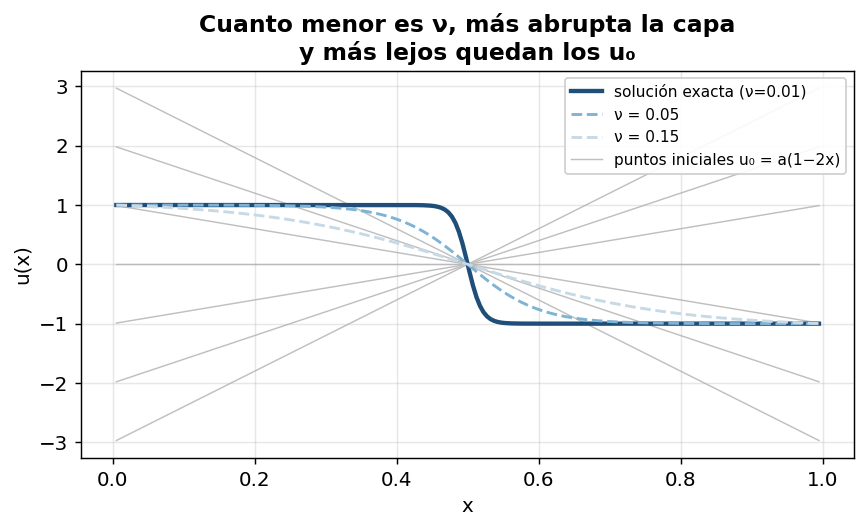

  → figuras/fig3a_problema.png


In [5]:
titulo("PARTE A · Burgers estacionaria con capa límite interna")

u_ex = solucion_exacta()
print(f"""
  −ν u'' + u u' = 0 ,   u(0) = {U_IZQ} ,  u(1) = {U_DER} ,   ν = {NU}

  Nodos interiores N           : {N}
  Paso de malla h              : {H:.5f}
  Anchura de la capa (≈ 2ν)    : {2*NU:.3f}   → unos {int(2*NU/H)} nodos la resuelven
  Péclet de celda  h·|u|/ν     : {H/NU:.2f}   (< 2, así que las diferencias
                              centradas no oscilan: el problema es duro
                              por no linealidad, no por discretización)

  Esto importa: si el problema fuera duro por una discretización inestable,
  ninguna estrategia de globalización lo arreglaría. Aquí la dificultad es
  genuinamente la no linealidad convectiva.
""")

fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot(MALLA, u_ex, color="#1f4e79", lw=2.4, label=f"solución exacta (ν={NU})")
for nu_alt, color in [(0.05, "#7fb3d5"), (0.15, "#c8d9e6")]:
    A = 1.0
    for _ in range(80):
        A = 1.0 / np.tanh(A / (4.0 * nu_alt))
    ax.plot(MALLA, A * np.tanh(A * (0.5 - MALLA) / (2.0 * nu_alt)),
            color=color, lw=1.6, ls="--", label=f"ν = {nu_alt}")
for a in AMPLITUDES:
    ax.plot(MALLA, a * (1 - 2 * MALLA), color="0.75", lw=0.8, zorder=0)
ax.plot([], [], color="0.75", lw=0.8, label="puntos iniciales u₀ = a(1−2x)")
ax.set_xlabel("x")
ax.set_ylabel("u(x)")
ax.set_title("Cuanto menor es ν, más abrupta la capa\ny más lejos quedan los u₀")
ax.legend(fontsize=8.5, loc="upper right")
fig.savefig(f"{SALIDA}/fig3a_problema.png", bbox_inches="tight")
plt.show()
print(f"  → {SALIDA}/fig3a_problema.png")

## Parte B · Las cuatro estrategias sobre los mismos 7 puntos iniciales


  PARTE B · Las cuatro estrategias sobre los mismos 7 puntos iniciales

  Familia de puntos iniciales:  u₀(x) = a·(1 − 2x),  a ∈ [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]
  (a = 1 es el perfil lineal que une las dos condiciones de frontera; los
   demás están cada vez más lejos de la solución.)

  Todas las corridas usan EXACTAMENTE el mismo paso de Newton inexacto, el
  mismo GMRES, el mismo precondicionador y el mismo término de forzado
  Eisenstat-Walker 2. Lo único que cambia es la estrategia de globalización.



    Newton inexacto (sin globalizar)     1/7


    Búsqueda de línea (Armijo)           5/7


    Región de confianza (dogleg)         3/7


    Continuación pseudo-transitoria      7/7

  (corrida completa: 33.4 s)

  ----------------------------------+--------+-------+-------------------------+---------------+--------------------
              estrategia            | éxitos |  tasa | iters. Newton (mediana) | J·v (mediana) | evals. F (mediana) 
  ----------------------------------+--------+-------+-------------------------+---------------+--------------------
   Newton inexacto (sin globalizar) |  1/7   |  14 % |            52           |     10,631    |       10,684       
      Búsqueda de línea (Armijo)    |  5/7   |  71 % |            88           |     3,114     |       3,481        
     Región de confianza (dogleg)   |  3/7   |  43 % |            54           |     3,174     |       3,242        
   Continuación pseudo-transitoria  |  7/7   | 100 % |            90           |      863      |        984         
  ----------------------------------+--------+-------+-------------------------+---------------+---------

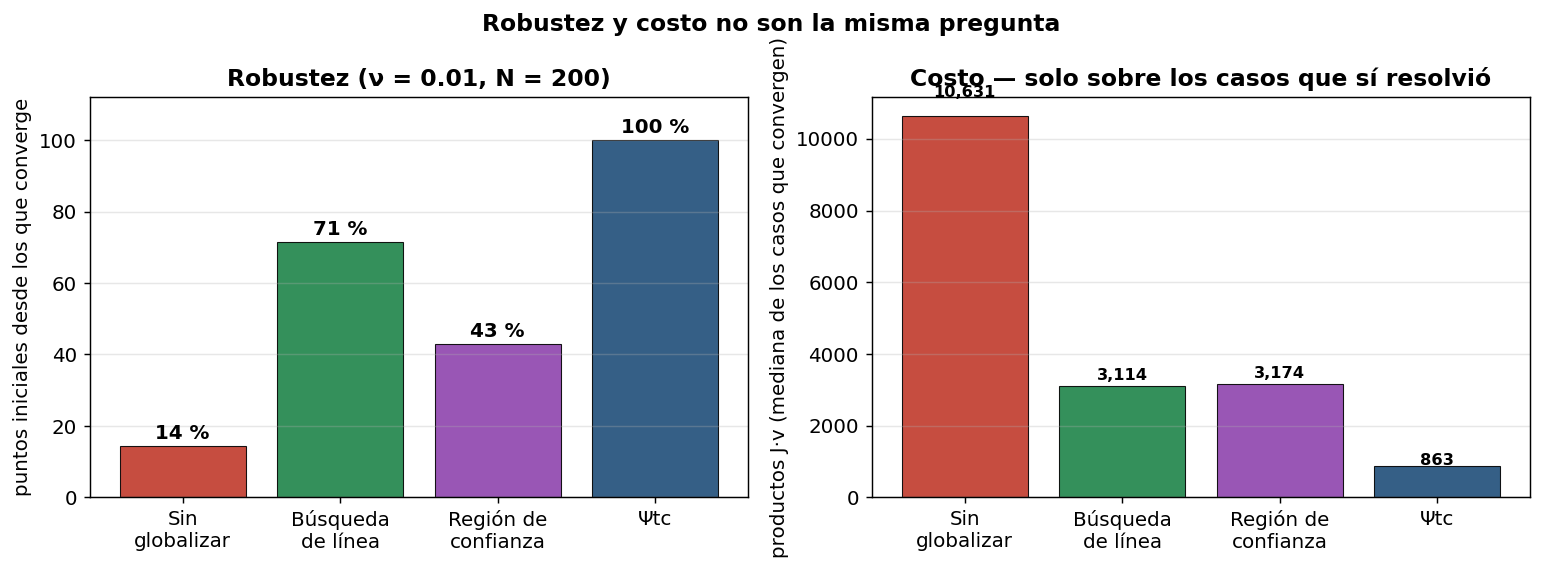


  → figuras/fig3b_exito.png


In [6]:
titulo("PARTE B · Las cuatro estrategias sobre los mismos 7 puntos iniciales")

print(f"""
  Familia de puntos iniciales:  u₀(x) = a·(1 − 2x),  a ∈ {AMPLITUDES}
  (a = 1 es el perfil lineal que une las dos condiciones de frontera; los
   demás están cada vez más lejos de la solución.)

  Todas las corridas usan EXACTAMENTE el mismo paso de Newton inexacto, el
  mismo GMRES, el mismo precondicionador y el mismo término de forzado
  Eisenstat-Walker 2. Lo único que cambia es la estrategia de globalización.
""")

resultados = {}
t0 = time.perf_counter()
for clave, nombre, color in ESTRATEGIAS:
    por_caso = []
    for a in AMPLITUDES:
        por_caso.append(resuelve(a * (1 - 2 * MALLA), clave, M))
    resultados[clave] = por_caso
    exitos = sum(h.convergio for h in por_caso)
    print(f"    {nombre:36s} {exitos}/{len(AMPLITUDES)}")
print(f"\n  (corrida completa: {time.perf_counter()-t0:.1f} s)\n")

filas = []
for clave, nombre, _c in ESTRATEGIAS:
    hs = resultados[clave]
    ok = [h for h in hs if h.convergio]
    filas.append([
        nombre,
        f"{len(ok)}/{len(hs)}",
        f"{100*len(ok)/len(hs):.0f} %",
        f"{int(np.median([h.n_newton for h in ok]))}" if ok else "—",
        f"{int(np.median([h.n_Jv for h in ok])):,}" if ok else "—",
        f"{int(np.median([h.n_F for h in ok])):,}" if ok else "—",
    ])
tabla(filas, ["estrategia", "éxitos", "tasa", "iters. Newton (mediana)",
              "J·v (mediana)", "evals. F (mediana)"])

# --- detalle caso por caso ---
print("\n  Detalle por punto inicial  (OK = convergió, ·· = no):\n")
encab = ["a"] + [n.split("(")[0].strip()[:16] for _c, n, _co in ESTRATEGIAS]
filas = []
for i, a in enumerate(AMPLITUDES):
    fila = [f"{a:+.0f}"]
    for clave, _n, _c in ESTRATEGIAS:
        h = resultados[clave][i]
        fila.append(f"OK {h.n_newton:3d}it" if h.convergio else "··")
    filas.append(fila)
tabla(filas, encab)

# --- figura de barras ---
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4))
nombres = [n for _c, n, _co in ESTRATEGIAS]
colores = [co for _c, _n, co in ESTRATEGIAS]
tasas = [100 * sum(h.convergio for h in resultados[c]) / len(AMPLITUDES)
         for c, _n, _co in ESTRATEGIAS]
etiquetas = ["Sin\nglobalizar", "Búsqueda\nde línea", "Región de\nconfianza", "Ψtc"]

barras = a1.bar(etiquetas, tasas, color=colores, alpha=0.9, edgecolor="black",
                linewidth=0.6)
for b, t in zip(barras, tasas):
    a1.text(b.get_x() + b.get_width() / 2, t + 2, f"{t:.0f} %",
            ha="center", fontweight="bold")
a1.set_ylim(0, 112)
a1.set_ylabel("puntos iniciales desde los que converge")
a1.set_title(f"Robustez (ν = {NU}, N = {N})")
a1.grid(axis="x", visible=False)

costos = []
for c, _n, _co in ESTRATEGIAS:
    ok = [h.n_Jv for h in resultados[c] if h.convergio]
    costos.append(np.median(ok) if ok else 0)
barras = a2.bar(etiquetas, costos, color=colores, alpha=0.9,
                edgecolor="black", linewidth=0.6)
for b, t in zip(barras, costos):
    if t:
        a2.text(b.get_x() + b.get_width() / 2, t * 1.05, f"{int(t):,}",
                ha="center", fontweight="bold", fontsize=9)
a2.set_ylabel("productos J·v (mediana de los casos que convergen)")
a2.set_title("Costo — solo sobre los casos que sí resolvió")
a2.grid(axis="x", visible=False)
fig.suptitle("Robustez y costo no son la misma pregunta",
             fontsize=13, fontweight="bold")
fig.savefig(f"{SALIDA}/fig3b_exito.png", bbox_inches="tight")
plt.show()
print(f"\n  → {SALIDA}/fig3b_exito.png")

## Parte C · La garantía del teorema, vista en una gráfica


  PARTE C · La garantía del teorema, vista en una gráfica

  Tomamos el caso a = 0 (u₀ ≡ 0, un punto inicial perfectamente razonable) y
  graficamos ‖F(u_k)‖ contra el trabajo gastado.

  Lo que hay que señalar: la curva roja SUBE. Newton sin globalizar no tiene
  ninguna obligación de mejorar; el paso completo puede empeorar el residuo
  y lo hace. Las otras tres curvas NO SUBEN NUNCA, y eso no es suerte: es
  exactamente lo que impone la condición de Armijo

    ‖F(x + λs)‖ ≤ (1 − αλ) ‖F(x)‖ ,   α = 1e-4,

  y su equivalente en región de confianza (aceptar solo si ρ > 0). El teorema
  de convergencia global no promete llegar a la raíz: promete que la función
  de mérito f = ½‖F‖² no aumenta y que se converge a un punto estacionario
  de f. Esta gráfica es esa promesa.

  ----------------------------------+-------------+------------+-----------+----------+-----------
              estrategia            | ‖F‖ inicial | ‖F‖ máximo | ‖F‖ final | converge | ¿empeora? 
  -----------------

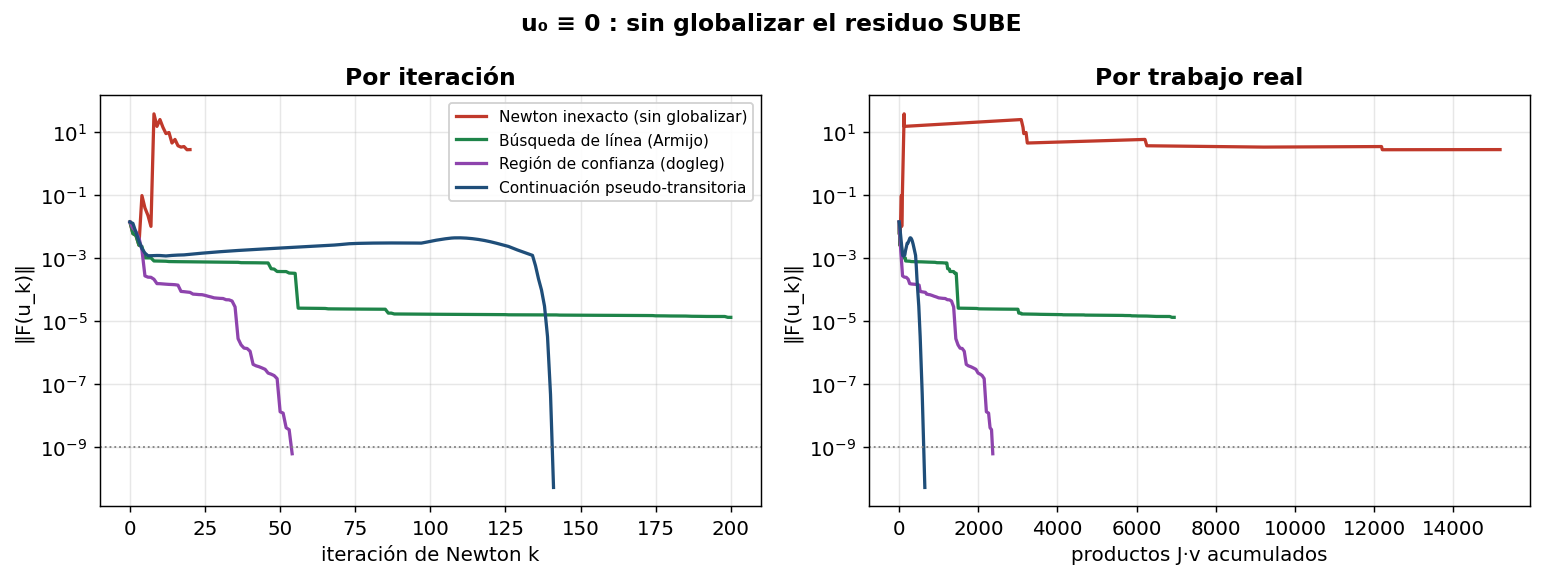


  → figuras/fig3c_residuales.png

  Un detalle que conviene entender antes de que lo pregunten:

  ‖F(u_numérica)‖                    = 6.14e-10   (convergió)
  ‖F(u_exacta muestreada)‖           = 2.59e-05   (¡no es cero!)
  error máximo entre ambas           = 3.00e-01
  la capa numérica cruza cero en x   = 0.4925   (la exacta, en 0.5000)

  Resolvimos el sistema discreto hasta 1e-9 y aun así la solución difiere de
  la continua en 0.3. No es un error del solver: la solución exacta
  muestreada NO es solución del sistema discreto, su residuo vale 2.6e-05.

  Lo que pasa es que la POSICIÓN de la capa está exponencialmente mal
  determinada: el Jacobiano tiene un autovalor de tamaño ~e^(−1/ν), o sea que
  desplazar la capa casi no cambia el residuo. Bajar ‖F‖ a 1e-9 no fija la
  capa mejor que eso. Es un recordatorio de que un residuo chico no equivale
  a una solución precisa: lo que acota el error es ‖J⁻¹‖·‖F‖, y aquí ‖J⁻¹‖ es
  enorme.



In [7]:
titulo("PARTE C · La garantía del teorema, vista en una gráfica")

idx = AMPLITUDES.index(0.0)
print(f"""
  Tomamos el caso a = 0 (u₀ ≡ 0, un punto inicial perfectamente razonable) y
  graficamos ‖F(u_k)‖ contra el trabajo gastado.

  Lo que hay que señalar: la curva roja SUBE. Newton sin globalizar no tiene
  ninguna obligación de mejorar; el paso completo puede empeorar el residuo
  y lo hace. Las otras tres curvas NO SUBEN NUNCA, y eso no es suerte: es
  exactamente lo que impone la condición de Armijo

    ‖F(x + λs)‖ ≤ (1 − αλ) ‖F(x)‖ ,   α = 1e-4,

  y su equivalente en región de confianza (aceptar solo si ρ > 0). El teorema
  de convergencia global no promete llegar a la raíz: promete que la función
  de mérito f = ½‖F‖² no aumenta y que se converge a un punto estacionario
  de f. Esta gráfica es esa promesa.
""")

filas = []
for clave, nombre, _c in ESTRATEGIAS:
    h = resultados[clave][idx]
    r = np.array(h.residuales)
    filas.append([nombre,
                  f"{r[0]:.2e}",
                  f"{r.max():.2e}",
                  f"{r[-1]:.2e}",
                  "sí" if h.convergio else "NO",
                  "nunca" if r.max() <= r[0] * (1 + 1e-12) else "SÍ, sube"])
tabla(filas, ["estrategia", "‖F‖ inicial", "‖F‖ máximo", "‖F‖ final",
              "converge", "¿empeora?"])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
for clave, nombre, color in ESTRATEGIAS:
    h = resultados[clave][idx]
    a1.semilogy(h.residuales, color=color, lw=1.8, label=nombre)
    trabajo = h.trabajo_acumulado
    a2.semilogy(trabajo, h.residuales[:len(trabajo)], color=color, lw=1.8,
                label=nombre)
for ax, xl in [(a1, "iteración de Newton k"),
               (a2, "productos J·v acumulados")]:
    ax.axhline(1e-9, color="0.5", ls=":", lw=1)
    ax.set_xlabel(xl)
    ax.set_ylabel("‖F(u_k)‖")
a1.set_title("Por iteración")
a2.set_title("Por trabajo real")
a1.legend(fontsize=8.5)
fig.suptitle("u₀ ≡ 0 : sin globalizar el residuo SUBE",
             fontsize=13, fontweight="bold")
fig.savefig(f"{SALIDA}/fig3c_residuales.png", bbox_inches="tight")
plt.show()
print(f"\n  → {SALIDA}/fig3c_residuales.png")

# --- la solución obtenida vs la exacta: un detalle que vale la pena ---
h_ok = next((resultados[c][idx] for c, _n, _co in ESTRATEGIAS
             if resultados[c][idx].convergio), None)
if h_ok is not None:
    u_ex = solucion_exacta()
    err = np.linalg.norm(h_ok.x - u_ex, np.inf)
    res_exacta = np.linalg.norm(F_burgers(u_ex))
    x_num = MALLA[np.argmin(np.abs(h_ok.x))]
    print(f"""
  Un detalle que conviene entender antes de que lo pregunten:

  ‖F(u_numérica)‖                    = {h_ok.residuales[-1]:.2e}   (convergió)
  ‖F(u_exacta muestreada)‖           = {res_exacta:.2e}   (¡no es cero!)
  error máximo entre ambas           = {err:.2e}
  la capa numérica cruza cero en x   = {x_num:.4f}   (la exacta, en 0.5000)

  Resolvimos el sistema discreto hasta 1e-9 y aun así la solución difiere de
  la continua en 0.{int(err*10):01d}. No es un error del solver: la solución exacta
  muestreada NO es solución del sistema discreto, su residuo vale {res_exacta:.1e}.

  Lo que pasa es que la POSICIÓN de la capa está exponencialmente mal
  determinada: el Jacobiano tiene un autovalor de tamaño ~e^(−1/ν), o sea que
  desplazar la capa casi no cambia el residuo. Bajar ‖F‖ a 1e-9 no fija la
  capa mejor que eso. Es un recordatorio de que un residuo chico no equivale
  a una solución precisa: lo que acota el error es ‖J⁻¹‖·‖F‖, y aquí ‖J⁻¹‖ es
  enorme.
""")

## Parte D · Ψtc gana, pero δ₀ es un parámetro de verdad


  PARTE D · Ψtc gana, pero δ0 es un parámetro de verdad

  La continuación pseudo-transitoria resuelve

    (I + δ J) s = −δ F ,     δ_{k+1} = δ_k · ‖F_k‖ / ‖F_{k+1}‖   (regla SER)

  o sea: integra du/dt = −F(u) con Euler implícito, empezando con pasos de
  tiempo cortos (muy amortiguados, casi máximo descenso) y alargándolos a
  medida que el residuo baja, hasta recuperar Newton puro al final.

  δ0 pequeño  → sobre-amortiguado: avanza, pero a paso de tortuga.
  δ0 grande   → prácticamente Newton puro: se pierde la robustez.

  Por defecto usamos δ0 = 1/‖F(u₀)‖, que es lo que recomienda la literatura,
  pero conviene saber que el método es sensible a esta elección.



  -------------------------------+----------+---------------+--------+-----------
                 δ0              | converge | iters. Newton |  J·v   | ‖F‖ final 
  -------------------------------+----------+---------------+--------+-----------
                0.01             |    NO    |      250      | 2,499  |  1.41e-02 
                 1               |    NO    |      250      | 2,772  |  6.08e-03 
   70.7  (= 1/‖F₀‖, por defecto) |    sí    |      141      |  863   |  5.22e-11 
               1e+04             |    sí    |       8       |  200   |  5.15e-10 
               1e+06             |    sí    |       9       |  315   |  1.56e-10 
               1e+09             |    NO    |      134      | 15,586 |  2.20e+00 
  -------------------------------+----------+---------------+--------+-----------


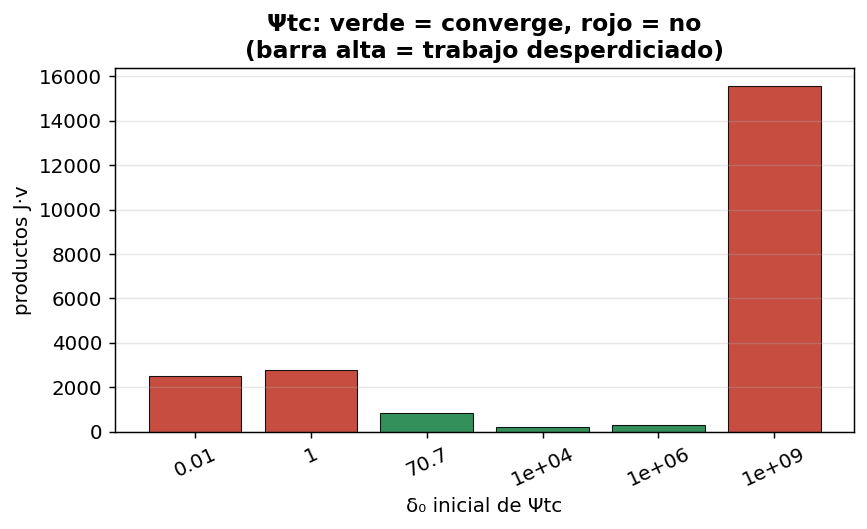


  → figuras/fig3d_ptc_delta.png


In [8]:
titulo("PARTE D · Ψtc gana, pero δ0 es un parámetro de verdad")

print("""
  La continuación pseudo-transitoria resuelve

    (I + δ J) s = −δ F ,     δ_{k+1} = δ_k · ‖F_k‖ / ‖F_{k+1}‖   (regla SER)

  o sea: integra du/dt = −F(u) con Euler implícito, empezando con pasos de
  tiempo cortos (muy amortiguados, casi máximo descenso) y alargándolos a
  medida que el residuo baja, hasta recuperar Newton puro al final.

  δ0 pequeño  → sobre-amortiguado: avanza, pero a paso de tortuga.
  δ0 grande   → prácticamente Newton puro: se pierde la robustez.

  Por defecto usamos δ0 = 1/‖F(u₀)‖, que es lo que recomienda la literatura,
  pero conviene saber que el método es sensible a esta elección.
""")

u0 = np.zeros(N)
n0 = np.linalg.norm(F_burgers(u0))
deltas = [1e-2, 1e0, 1.0 / n0, 1e4, 1e6, 1e9]
filas = []
exitos, costos = [], []
for d0 in deltas:
    h = nk_lib.newton_krylov(F_burgers, u0, globalizacion="ptc",
                             forzado="ew2", tol=1e-9, max_iter=250,
                             precond=M, gmres_maxiter=100,
                             max_evals_F=15000, ptc_delta0=d0)
    etiqueta = f"{d0:.3g}" + ("  (= 1/‖F₀‖, por defecto)"
                              if abs(d0 - 1.0 / n0) < 1e-9 else "")
    filas.append([etiqueta, "sí" if h.convergio else "NO",
                  h.n_newton, f"{h.n_Jv:,}", f"{h.residuales[-1]:.2e}"])
    exitos.append(h.convergio)
    costos.append(h.n_Jv)
tabla(filas, ["δ0", "converge", "iters. Newton", "J·v", "‖F‖ final"])

fig, ax = plt.subplots(figsize=(6.8, 4.2))
colores = ["#1e8449" if e else "#c0392b" for e in exitos]
ax.bar(range(len(deltas)), costos, color=colores, alpha=0.9,
       edgecolor="black", linewidth=0.6)
ax.set_xticks(range(len(deltas)))
ax.set_xticklabels([f"{d:.3g}" for d in deltas], rotation=25)
ax.set_xlabel("δ₀ inicial de Ψtc")
ax.set_ylabel("productos J·v")
ax.set_title("Ψtc: verde = converge, rojo = no\n(barra alta = trabajo desperdiciado)")
ax.grid(axis="x", visible=False)
fig.savefig(f"{SALIDA}/fig3d_ptc_delta.png", bbox_inches="tight")
plt.show()
print(f"\n  → {SALIDA}/fig3d_ptc_delta.png")

## Parte E · Contra scipy.optimize.newton_krylov

In [9]:
titulo("PARTE E · Contra scipy.optimize.newton_krylov")

from scipy.optimize import newton_krylov as scipy_nk
filas = []
for a in AMPLITUDES:
    u0 = a * (1 - 2 * MALLA)
    try:
        t0 = time.perf_counter()
        u = scipy_nk(F_burgers, u0, method="lgmres", f_tol=1e-9,
                     maxiter=200, verbose=False)
        t = time.perf_counter() - t0
        estado = f"OK ({t*1000:.0f} ms)" if np.linalg.norm(F_burgers(u)) < 1e-8 else "··"
    except Exception:
        estado = "··"
    h_ptc = resultados["ptc"][AMPLITUDES.index(a)]
    filas.append([f"{a:+.0f}", estado,
                  f"OK ({h_ptc.n_newton} it)" if h_ptc.convergio else "··"])
tabla(filas, ["a", "scipy.optimize.newton_krylov", "nuestra Ψtc"])

print("""
  scipy.optimize.newton_krylov implementa Newton-Krylov con búsqueda de línea
  (globalización "armijo"), que es una elección excelente por defecto. No
  incluye continuación pseudo-transitoria, y en este problema convectivo eso
  se nota. Para casos así, la herramienta a la mano es PETSc SNES
  (-snes_type newtonls / newtontr, -snes_mf_operator) o SUNDIALS KINSOL,
  que sí traen Ψtc y continuación en parámetros.
""")


  PARTE E · Contra scipy.optimize.newton_krylov


  ----+------------------------------+-------------
   a  | scipy.optimize.newton_krylov | nuestra Ψtc 
  ----+------------------------------+-------------
   -3 |              ··              | OK (108 it) 
   -2 |              ··              |  OK (90 it) 
   -1 |              ··              |  OK (81 it) 
   +0 |         OK (472 ms)          | OK (141 it) 
   +1 |          OK (88 ms)          |  OK (55 it) 
   +2 |          OK (35 ms)          |  OK (86 it) 
   +3 |          OK (42 ms)          | OK (130 it) 
  ----+------------------------------+-------------

  scipy.optimize.newton_krylov implementa Newton-Krylov con búsqueda de línea
  (globalización "armijo"), que es una elección excelente por defecto. No
  incluye continuación pseudo-transitoria, y en este problema convectivo eso
  se nota. Para casos así, la herramienta a la mano es PETSc SNES
  (-snes_type newtonls / newtontr, -snes_mf_operator) o SUNDIALS KINSOL,
  que sí traen Ψtc y continuación en parámetros.



In [10]:
titulo("FIN DEL EJERCICIO 3")


  FIN DEL EJERCICIO 3
